In [1]:
import sys
sys.path.append('..')

from eval_lsh import *

def compute_map_mrr(scores, labels):
    ranking = scores.argsort(dim=1, descending=True)
    ranked_output = torch.gather(labels, dim=1, index=ranking)

    MRR = (1 / (ranked_output.argmax(dim=1) + 1)).mean().item()

    MAP = (torch.cumsum(ranked_output, dim=1) * ranked_output).float()
    MAP /= (torch.arange(ranked_output.shape[1]) + 1)
    MAP /= torch.sum(ranked_output, dim=1, keepdim=True)
    MAP = MAP.sum(dim=1).mean().item()
    return MAP, MRR

In [79]:
expt_id = "S28021253"
# expt_id = "A01091914"
dataset = "speech" if expt_id.startswith("S") else "audio"
hasher_expt_num = 3 if dataset == "speech" else 24
DEVICE = "cuda:6"

hasher_expt_root = f"../hashing/{expt_id}/{hasher_expt_num}/"
saved_gt_path = f"../hashing/{expt_id}_embeds_gt.pkl"

hasher = torch.load(f"{hasher_expt_root}/hasher_best.pt", map_location=DEVICE)
hasher = hasher.eval()

savedict = torch.load(saved_gt_path)
corpus_embedded = savedict["corpus"].cpu()
labels = savedict["labels"].cpu()
global_scores = savedict["scores"].cpu()
test_query_embedded = savedict["queries"].cpu()
print("Loaded ground truth")

Loaded ground truth


In [80]:
with torch.no_grad():
    corpus_embedded_out = []
    for i in range(0,len(corpus_embedded),200):
        corpus_embedded_out.append(hasher[1](corpus_embedded[i:i+200].to(DEVICE)).cpu())
    corpus_embedded = torch.vstack(corpus_embedded_out)
    test_query_embedded = hasher[0](test_query_embedded.to(DEVICE)).cpu()

In [81]:
netscores = test_query_embedded @ corpus_embedded.T
MAP, MRR = compute_map_mrr(netscores, labels)
print(f"Dot Product Scores -- MAP: {MAP:.4f},{MRR:.4f}")
perf["IP"] = (MAP, MRR)

Dot Product Scores -- MAP: 0.0038,0.0022


In [82]:
arr = [[0.0064,0.0038],
[0.0062,0.0030],
[0.0028,0.0012],
[0.0038,0.0022]]
arr = np.array(arr)
np.mean(arr,0), np.std(arr,0)

(array([0.0048 , 0.00255]), array([0.00154272, 0.00096307]))

In [51]:
perf = dict()

# 0. s(q,c) = OPAS_{s}(q,c)

In [52]:
MAP, MRR = compute_map_mrr(global_scores, labels)
print(f"Original OPAS Scores -- MAP: {MAP:.4f}, MRR: {MRR:.4f}")
perf["OPAS"] = (MAP, MRR)

Original OPAS Scores -- MAP: 0.9918, MRR: 0.9917


# 1. $s(q,c) = \langle q,c \rangle$

In [53]:
netscores = test_query_embedded @ corpus_embedded.T
MAP, MRR = compute_map_mrr(netscores, labels)
print(f"Dot Product Scores -- MAP: {MAP:.4f}, MRR: {MRR:.4f}")
perf["IP"] = (MAP, MRR)

Dot Product Scores -- MAP: 0.0038, MRR: 0.0022


# 2. $s(q,c) = \frac{\langle q,c \rangle}{||q||\cdot||c||}$

In [54]:
netscores = test_query_embedded @ corpus_embedded.T / (torch.norm(test_query_embedded, dim=-1, keepdim=True) * torch.norm(corpus_embedded, dim=-1, keepdim=True).T)
MAP, MRR = compute_map_mrr(netscores, labels)
print(f"Cosine Similarity Scores -- MAP: {MAP:.4f}, MRR: {MRR:.4f}")
perf["CS"] = (MAP, MRR)

Cosine Similarity Scores -- MAP: 0.5676, MRR: 0.5867


In [55]:
import pandas as pd
df = pd.DataFrame(perf).T
df = df.reset_index()
df.columns = ["Method", "MAP", "MRR"]
df

,Method,MAP,MRR
0,OPAS,0.991756,0.991719
1,IP,0.003805,0.002163
2,CS,0.567633,0.586665


# 3. FAISS

In [23]:
import faiss
import pickle

from plot_params import *
from itertools import chain

dataset = "audio"
with open(f"data/lsh_multi_final_{dataset}.pkl", "rb") as f:
    lss = pickle.load(f)

best_idx = 29 if dataset == "audio" else 24

best_perf = lss[best_idx][3:]     # idx 29 has the best hparam set
opas_map = best_perf[::3]
opas_ret = best_perf[1::3]
kvals = list(chain([10], opas_ret[1:]))

In [24]:
def get_faiss_map(lsh, k):
    _, I = lsh.search(test_query_embedded.numpy(), k=k)
    I = torch.from_numpy(I)
    ret_scores = global_scores.gather(1, I)
    ret_labels = labels.gather(1, I)
    ap = []
    for i in range(len(test_query_embedded)):
        total_rel = labels[i].sum()
        l = ret_labels[i]
        scores = ret_scores[i]
        ap.append(average_precision_score(l, scores))
    return np.mean(ap)

def faiss_map_for_k_list(lsh, klist):
    _map = dict()
    for k in tqdm(list(klist)):
        try:
            _map[k] = get_faiss_map(lsh, int(k))
        except:
            print(f"Error with k={k}")
            continue
    _map = np.array(list(_map.items()))
    return _map[:,0], _map[:,1]

In [25]:
d = 4000 #corpus_embedded.shape[1]
try:
    with open(f"data/faiss_{dataset}.pkl", "rb") as f:
        all_map = pickle.load(f)
except:
    raise
    all_map = dict()
    for m in [10, 20, 50, 100][:1]:
        # m = 10
        lsh = faiss.IndexLSH(d, m)
        lsh.train(corpus_embedded.numpy())
        lsh.add(corpus_embedded.numpy())
        _map = dict()
        for k in tqdm(kvals, desc=f"LSH evaluation (m={m})"):
            _map[k] = get_faiss_map(lsh, int(k))
        _map = np.array(list(_map.items()))
        all_map[m] = _map
        
    with open(f"data/faiss_{dataset}.pkl", "wb") as f:
        pickle.dump(all_map, f)

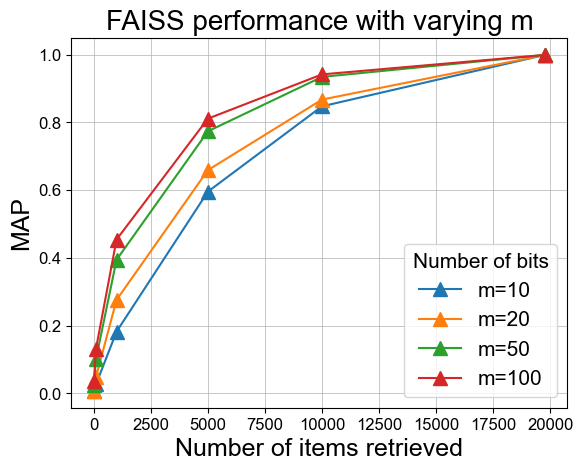

In [26]:
list(all_map.items())

from plot_params import *

for m in all_map.keys():
    if type(m) != int:
        continue
    plt.plot(all_map[m][:,0], all_map[m][:,1], "^-", markersize=10, label=f"m={m}")
plt.title("FAISS performance with varying m", fontsize=title_fontsize)
plt.xticks(fontsize=label_fontsize)
plt.yticks(fontsize=label_fontsize)
plt.legend(title="Number of bits", fontsize=15, title_fontsize=15)
plt.xlabel("Number of items retrieved", fontsize=axis_fontsize)
plt.ylabel("MAP", fontsize=axis_fontsize)
plt.grid(linewidth=0.5)
# plt.savefig("faiss_audio_m_fixedfonts.pdf", bbox_inches="tight")
plt.show()

## Compare FAISS with OPAS + trained hplane

In [27]:
if dataset == "speech":
    all_map["aligned"] = all_map[10]

faiss_map = all_map["aligned"][:,1]
faiss_ret = all_map["aligned"][:,0]

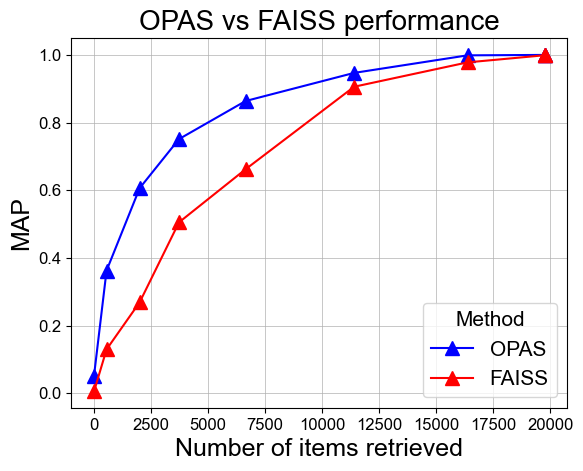

In [28]:
plt.plot(opas_ret, opas_map, "^-", markersize=10, label="OPAS", color="blue")#tab:blue")
plt.plot(faiss_ret, faiss_map, "^-", markersize=10, label="FAISS", color="red")#tab:orange")
plt.title("OPAS vs FAISS performance", fontsize=title_fontsize)
plt.xticks(fontsize=label_fontsize)
plt.yticks(fontsize=label_fontsize)
plt.legend(title="Method", fontsize=15, title_fontsize=15)
plt.xlabel("Number of items retrieved", fontsize=axis_fontsize)
plt.ylabel("MAP", fontsize=axis_fontsize)
plt.grid(linewidth=0.5)
# plt.savefig("opas_vs_faiss_fixedfonts.pdf", bbox_inches="tight")
plt.show()

# Using FAISS Indexes

In [29]:
import faiss
from itertools import chain

indexes = {
    "flatl2": faiss.IndexFlatL2,
    "flatip": faiss.IndexFlatIP, 
}
indexes_map = {
    "opas": (opas_ret, opas_map),
    "faiss": (faiss_ret, faiss_map),
}

for index_name in indexes.keys():
    try:
        indexes_map[index_name] = all_map[index_name].T
    except:
        raise
        index = indexes[index_name](d)
        index.add(corpus_embedded.numpy())
        index.nprobe = 5
        ret_, map_ = faiss_map_for_k_list(index, kvals)
        all_map[index_name] = np.array([ret_, map_]).T
        indexes_map[index_name] = all_map[index_name]

# try:
#     flatl2_ret, flatl2_map = all_map["flatl2"].T
#     flatip_ret, flatip_map = all_map["flatip"].T
    
# except:
#     index_flat = faiss.IndexFlatL2(d)
#     index_flat.add(corpus_embedded.numpy())
#     index_flat.nprobe = 5

#     index_flatip = faiss.IndexFlatIP(d)
#     index_flatip.add(corpus_embedded.numpy())
#     index_flatip.nprobe = 5

#     kvals = list(chain([10], opas_ret[1:]))

#     flatl2_ret, flatl2_map = faiss_map_for_k_list(index_flat, kvals)
#     flatip_ret, flatip_map = faiss_map_for_k_list(index_flatip, kvals)

In [30]:
try:
    flativf_ret, flativf_map = all_map["flativf"].T

except:
    raise
    quant = faiss.IndexFlatL2(d)
    index_ivf = faiss.IndexIVFFlat(quant, d, 2, faiss.METRIC_L2)
    index_ivf.train(corpus_embedded.numpy())
    index_ivf.add(corpus_embedded.numpy())

    kvals = list(chain([10], opas_ret[1:]))
    flativf_ret, flativf_map = faiss_map_for_k_list(index_ivf, kvals)

In [31]:
# # all_map["flatl2"] = np.array([flatl2_ret, flatl2_map]).T
# # all_map["flatip"] = np.array([flatip_ret, flatip_map]).T
# all_map["flativf"] = np.array([flativf_ret, flativf_map]).T

# with open(f"data/faiss_{dataset}.pkl", "wb") as f:
#     pickle.dump(all_map, f)

In [32]:
indexes_map.keys()

dict_keys(['opas', 'faiss', 'flatl2', 'flatip'])

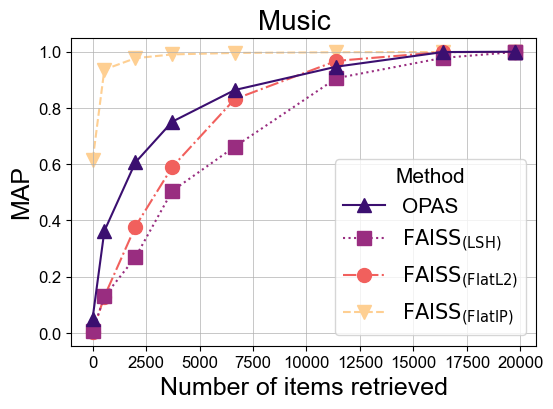

In [33]:
plt.figure(figsize=(6,4))

MARKERS = ["^", "s", "o","v"]
LINESTYLES = ["-",":", "-.", "--"]

linewidth = 1.5
kwargs = {
    "linewidth": linewidth,
    "alpha": 1,
    # "marker": "^",
    "markersize": 10,
    # "linestyle": "-",
}

methodnames = {
    "opas": "OPAS",
    "flatl2": r"$\rm FAISS_{(Flat L2)}$",
    "flatip": r"$\rm FAISS_{(Flat IP)}$",
    "faiss": r"$\rm FAISS_{(LSH)}$"
}
colors = plt.cm.magma(np.linspace(0.2, 0.9, len(indexes_map)))
# colors = ["blue", "red", "green"]
for n, (method, data) in enumerate(indexes_map.items()):
    ret_, map_ = data
    plt.plot(ret_, map_, label=methodnames[method], color=colors[0], marker=MARKERS[n], linestyle=LINESTYLES[n], zorder=4-n, **kwargs)
    colors = colors[1:]

# plt.plot(opas_ret, opas_map, label="OPAS", color="blue", **kwargs)
# plt.plot(faiss_ret, faiss_map, label=r"$\rm FAISS_{(LSH)}$", color="red", **kwargs)
# plt.plot(flatl2_ret, flatl2_map, label=r"$\rm FAISS_{(Flat L2)}$", color="green", **kwargs)
# plt.plot(flatip_ret, flatip_map, label=r"$\rm FAISS_{(Flat IP)}$", color="orange", **kwargs)
# plt.plot(flativf_ret, flativf_map, "^-", label="FAISS (Flat IVF L2)", color="orange", **kwargs)
dataset_name = "music" if dataset == "audio" else "speech"
plt.title(f"{dataset_name.capitalize()}", fontsize=title_fontsize, position=(0.48, 1.05))
plt.xticks(fontsize=label_fontsize)
plt.yticks(fontsize=label_fontsize)
plt.legend(title="Method", fontsize=legend_fontsize, title_fontsize=legend_fontsize)
plt.xlabel("Number of items retrieved", fontsize=axis_fontsize)
plt.ylabel("MAP", fontsize=axis_fontsize)
plt.grid(linewidth=0.5)
plt.savefig(f"opas_vs_faiss_{dataset}_fixedfonts.pdf", bbox_inches="tight")
plt.show()

# tmp

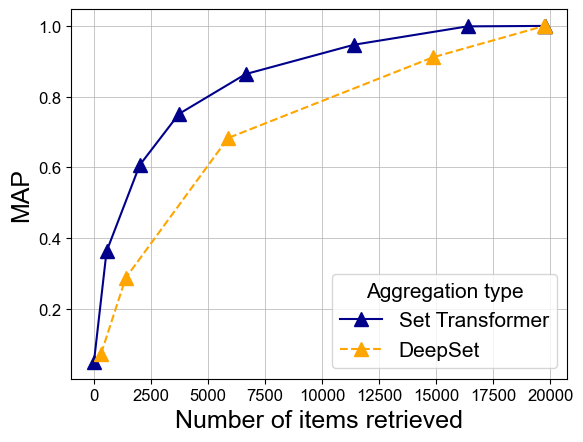

In [39]:
lsss = [0.07375, 314.56, 1.18, 0.2875, 1392.4, 4.6, 0.683125, 5880.22, 10.93, 0.91125, 14853.98, 14.58, 1.0, 19737.13, 16.0, 1.0, 19760.0, 16.0]
ds_ret, ds_map = lsss[1::3], lsss[0::3]

plt.plot(opas_ret, opas_map, "^-", markersize=10, label="Set Transformer", color="darkblue")#tab:blue")
plt.plot(ds_ret, ds_map, "^--", markersize=10, label="DeepSet", color="orange")#tab:orange")
plt.xticks(fontsize=label_fontsize)
plt.yticks(fontsize=label_fontsize)
plt.legend(title="Aggregation type", fontsize=15, title_fontsize=15)
plt.xlabel("Number of items retrieved", fontsize=axis_fontsize)
plt.ylabel("MAP", fontsize=axis_fontsize)
plt.grid(linewidth=0.5)
plt.savefig("set_xfm_vs_deepset_fixedfonts.pdf", bbox_inches="tight")
plt.show()

NameError: name 'label_fontsize' is not defined

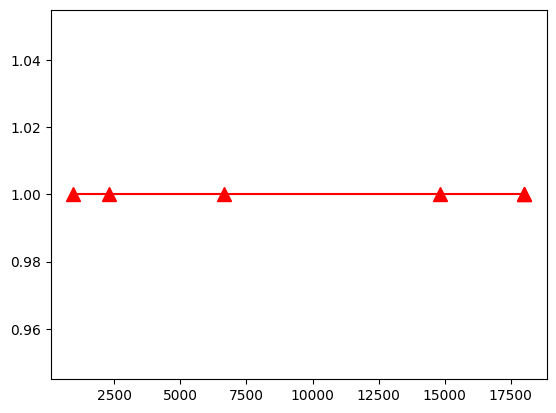

In [1]:
import matplotlib.pyplot as plt

lsss = [1.0, 947.11, 10.0, 1.0, 2297.26, 10.0, 1.0, 6637.9, 10.0, 1.0, 14822.15, 10.0, 1.0, 17995.44, 10.0, 1.0, 18000.0, 10.0]
ds_ret, ds_map = lsss[1::3], lsss[0::3]

plt.plot(ds_ret, ds_map, "^-", markersize=10, color="red")#tab:orange")
plt.xticks(fontsize=label_fontsize)
plt.yticks(fontsize=label_fontsize)
plt.legend(title="Aggregation type", fontsize=15, title_fontsize=15)
plt.xlabel("Number of items retrieved", fontsize=axis_fontsize)
plt.ylabel("MAP", fontsize=axis_fontsize)
plt.grid(linewidth=0.5)
# plt.savefig("set_xfm_vs_deepset.pdf", bbox_inches="tight")
plt.show()